# **RAG Pipelines: Data Ingestion to VectorDB Pipeline**

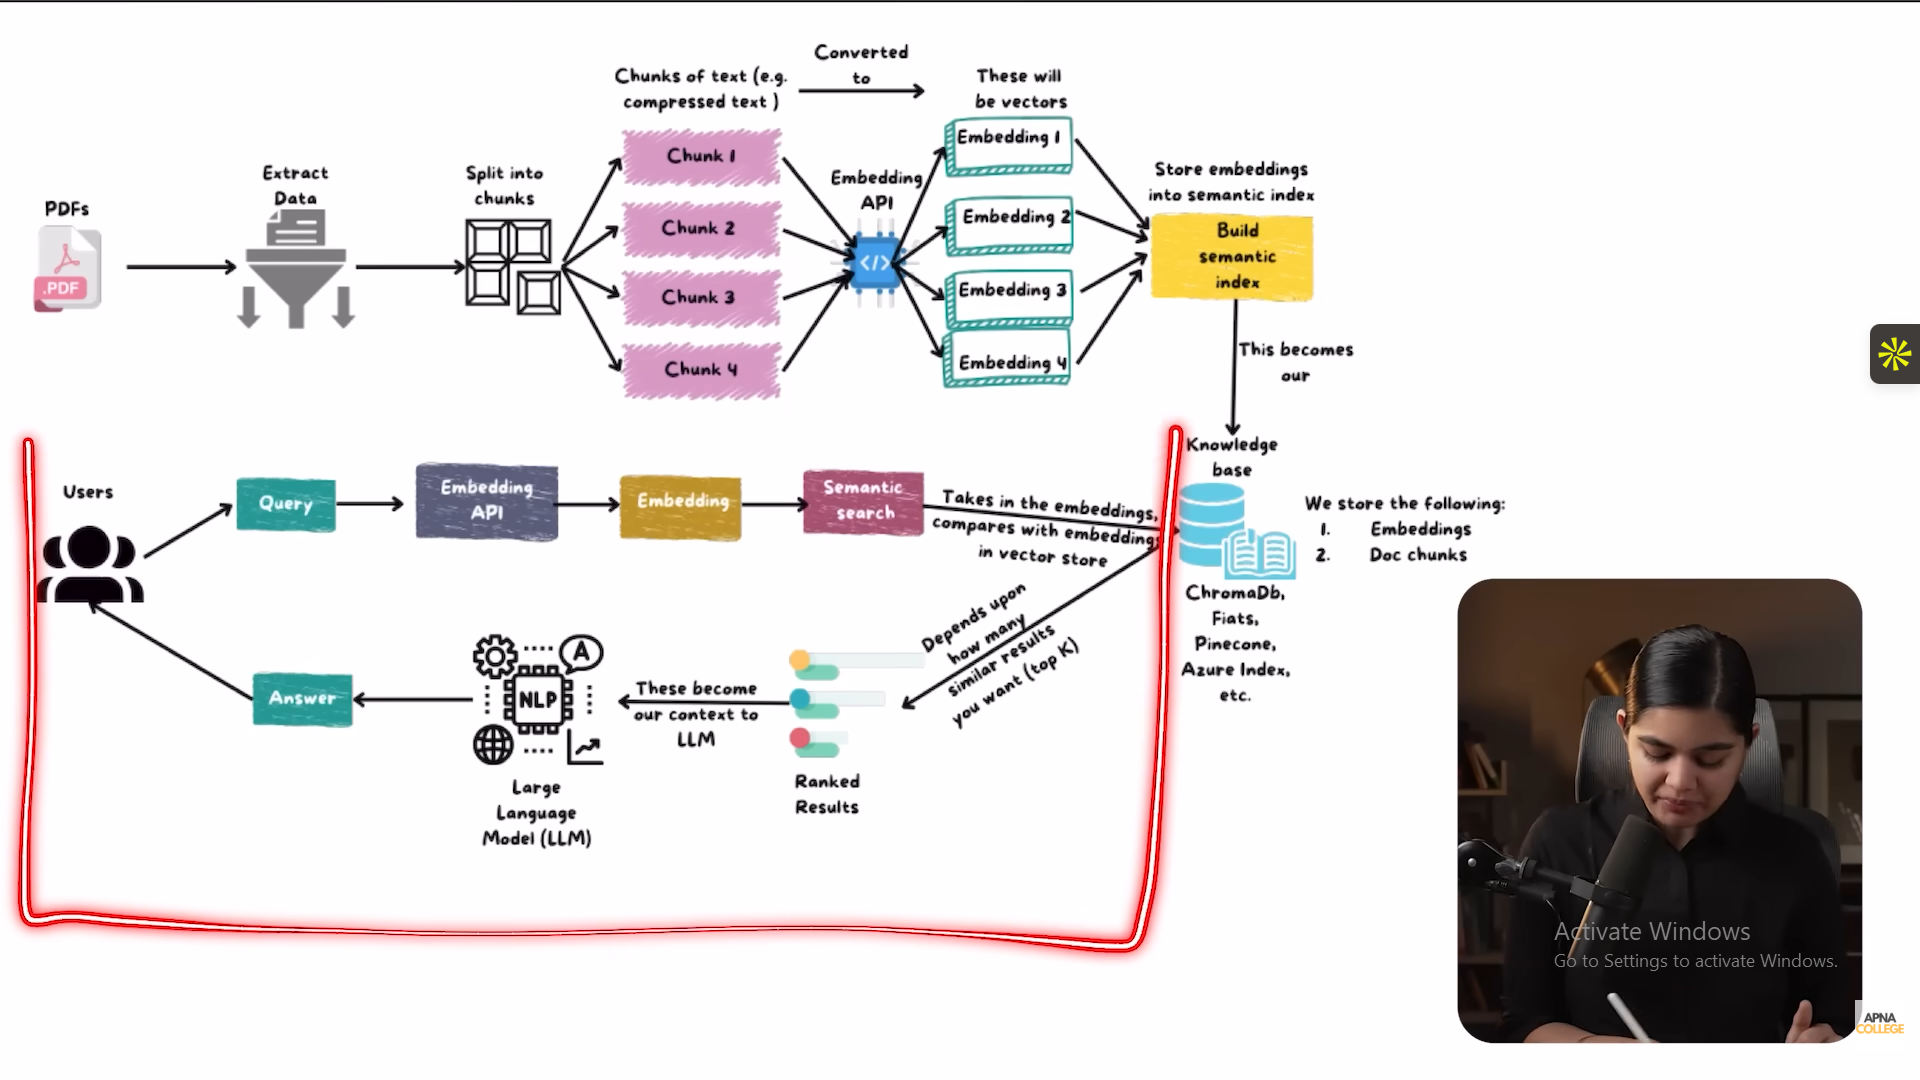

### Embedding And VectorStoreDB

In [59]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters.character import RecursiveCharacterTextSplitter
from pathlib import Path

In [60]:
### Read all the pdf's inside the directory
def process_all_pdfs(pdf_directory):
    """Process all PDF files in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)
    
    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))
    
    print(f"Found {len(pdf_files)} PDF files to process")
    
    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
            
            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDFs in the data directory
all_pdf_documents = process_all_pdfs("../data")

Found 4 PDF files to process

Processing: 390 - 73.Queue-LL.pdf
  ✓ Loaded 2 pages

Processing: 390 - 82.Selection-Sort.pdf
  ✓ Loaded 2 pages

Processing: Determinants 03 _ Class Notes - Prayas_2.0_Determinant_Rajeev Sir _ Lecture - 3 (1) 22-10-2021_compressed.pdf
  ✓ Loaded 30 pages

Processing: Work Energy Power 02 _ Class Notes - Work power energy lec-02 ;08-10-2021 (2) (2).pdf
  ✓ Loaded 36 pages

Total documents loaded: 70


In [61]:
all_pdf_documents

[Document(metadata={'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20190103112422Z00'00'", 'title': '120. Queue LL', 'moddate': "D:20190103112422Z00'00'", 'source': '..\\data\\pdf\\390 - 73.Queue-LL.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'source_file': '390 - 73.Queue-LL.pdf', 'file_type': 'pdf'}, page_content='Queue using Linked List\n#include <stdio.h>\n#include <stdlib.h>\nstruct Node\n{\n    int data;\n    struct Node *next;\n    \n}*front=NULL,*rear=NULL;\nvoid enqueue(int x)\n{\n    struct Node *t;\n    t=(struct Node*)malloc(sizeof(struct Node));\n    if(t==NULL)\n        printf("Queue is FUll\\n");\n    else\n    {\n        t->data=x;\n        t->next=NULL;\n        if(front==NULL)\n            front=rear=t;\n        else\n        {\n            rear->next=t;\n            rear=t;\n        }\n    }\n    \n}\nint dequeue()\n{\n    int x=-1;\n    struct Node* t;\n    \n    if(front==NULL)'),
 Document(meta

In [62]:
### Text splitting get into chunks

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [63]:
chunks=split_documents(all_pdf_documents)
chunks

Split 70 documents into 4 chunks

Example chunk:
Content: Queue using Linked List
#include <stdio.h>
#include <stdlib.h>
struct Node
{
    int data;
    struct Node *next;
    
}*front=NULL,*rear=NULL;
void enqueue(int x)
{
    struct Node *t;
    t=(struct ...
Metadata: {'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20190103112422Z00'00'", 'title': '120. Queue LL', 'moddate': "D:20190103112422Z00'00'", 'source': '..\\data\\pdf\\390 - 73.Queue-LL.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'source_file': '390 - 73.Queue-LL.pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20190103112422Z00'00'", 'title': '120. Queue LL', 'moddate': "D:20190103112422Z00'00'", 'source': '..\\data\\pdf\\390 - 73.Queue-LL.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'source_file': '390 - 73.Queue-LL.pdf', 'file_type': 'pdf'}, page_content='Queue using Linked List\n#include <stdio.h>\n#include <stdlib.h>\nstruct Node\n{\n    int data;\n    struct Node *next;\n    \n}*front=NULL,*rear=NULL;\nvoid enqueue(int x)\n{\n    struct Node *t;\n    t=(struct Node*)malloc(sizeof(struct Node));\n    if(t==NULL)\n        printf("Queue is FUll\\n");\n    else\n    {\n        t->data=x;\n        t->next=NULL;\n        if(front==NULL)\n            front=rear=t;\n        else\n        {\n            rear->next=t;\n            rear=t;\n        }\n    }\n    \n}\nint dequeue()\n{\n    int x=-1;\n    struct Node* t;\n    \n    if(front==NULL)'),
 Document(meta

## Embedding and VectorStoreDB

In [64]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [65]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        """
        Initialize the embedding manager
        
        Args:
            model_name: Hugging Face model name for sentence transformer"""
        self.model_name = model_name
        self.model = None
        self._load_model()
        
    def _load_model(self):
        """Load the sentence transformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}...")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise e
        
    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """Generate embeddings for a list of documents

        Args:
            texts: List of document texts to embed

        Returns:
            numpy array of embeddings with shape (num_texts, embedding_dim)"""
        if self.model is None:
            raise ValueError("Embedding model is not loaded.")
        try:
            print(f"Generating embeddings for {len(texts)} documents...")
            embeddings = self.model.encode(texts, show_progress_bar=True)
            print("Embeddings generated successfully.")
            return np.array(embeddings)
        except Exception as e:
            print(f"Error generating embeddings: {e}")
            raise e


## Initializa the smbedding manager

embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1807.36it/s]


Model loaded successfully. Embedding dimension: 384


C:\Users\HP\AppData\Local\Temp\ipykernel_23300\2968499620.py:19: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


## VectorStoreDB

In [66]:
import os

class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""

    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection to use
            persist_directory: Directory to persist the ChromaDB database
        """

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize the ChromaDB client and collection"""
        try:
            # Create Persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)

            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "Collection of PDF document embeddings"}
            )

            print(f"Vector store initialized, Collection: {self.collection_name}" )
            print(f"Existing documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise 
    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store

        Args:
            documents: List of Langchain document objects (e.g., Document instances)
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents and embeddings must match.")
        
        print(f"Adding {len(documents)} documents to the vector store...")

        #Prepare data for chromaDB
        ids=[]
        metadatas=[]
        documents_text=[]
        embeddings_list = []

        for i,(doc,embedding) in enumerate(zip(documents, embeddings)):
            # Generate a unique ID for each document
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)

            # Prepare metadata
            metadata=dict(doc.metadata)
            metadata['doc_index']=i
            metadata['content_length']=len(doc.page_content)
            metadatas.append(metadata)

            #Document content
            documents_text.append(doc.page_content)

            #Embedding
            embeddings_list.append(embedding.tolist()) # Convert numpy array to list for JSON serialization
        try:
            self.collection.add(
                ids=ids,
                metadatas=metadatas,
                documents=documents_text,
                embeddings=embeddings_list
            )
            print(f"Successfully added {len(documents)} documents to vector store.")
            print(f"Total documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise 

vectorstore = VectorStore()
vectorstore

Vector store initialized, Collection: pdf_documents
Existing documents in collection: 16


In [67]:
chunks

[Document(metadata={'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20190103112422Z00'00'", 'title': '120. Queue LL', 'moddate': "D:20190103112422Z00'00'", 'source': '..\\data\\pdf\\390 - 73.Queue-LL.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1', 'source_file': '390 - 73.Queue-LL.pdf', 'file_type': 'pdf'}, page_content='Queue using Linked List\n#include <stdio.h>\n#include <stdlib.h>\nstruct Node\n{\n    int data;\n    struct Node *next;\n    \n}*front=NULL,*rear=NULL;\nvoid enqueue(int x)\n{\n    struct Node *t;\n    t=(struct Node*)malloc(sizeof(struct Node));\n    if(t==NULL)\n        printf("Queue is FUll\\n");\n    else\n    {\n        t->data=x;\n        t->next=NULL;\n        if(front==NULL)\n            front=rear=t;\n        else\n        {\n            rear->next=t;\n            rear=t;\n        }\n    }\n    \n}\nint dequeue()\n{\n    int x=-1;\n    struct Node* t;\n    \n    if(front==NULL)'),
 Document(meta

In [68]:
### Convert the text to embeddings
texts=[doc.page_content for doc in chunks]

## Generate the Embeddings

embeddings=embedding_manager.generate_embeddings(texts)

##store int he vector dtaabase
vectorstore.add_documents(chunks,embeddings)

Generating embeddings for 4 documents...


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]


Embeddings generated successfully.
Adding 4 documents to the vector store...
Successfully added 4 documents to vector store.
Total documents in collection: 20


## Retriever Pipeline from VectorStoreDB

In [69]:
# 52:00 
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever
        
        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]
        
        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )
            
            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=RAGRetriever(vectorstore,embedding_manager)

In [70]:
rag_retriever

In [71]:
rag_retriever.retrieve("Write Queueue Algorithm")

Retrieving documents for query: 'Write Queueue Algorithm'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 documents...


Batches: 100%|██████████| 1/1 [00:00<00:00, 22.49it/s]

Embeddings generated successfully.
Retrieved 5 documents (after filtering)


[{'id': 'doc_80f11a26_0',
  'content': 'Queue using Linked List\n#include <stdio.h>\n#include <stdlib.h>\nstruct Node\n{\n    int data;\n    struct Node *next;\n    \n}*front=NULL,*rear=NULL;\nvoid enqueue(int x)\n{\n    struct Node *t;\n    t=(struct Node*)malloc(sizeof(struct Node));\n    if(t==NULL)\n        printf("Queue is FUll\\n");\n    else\n    {\n        t->data=x;\n        t->next=NULL;\n        if(front==NULL)\n            front=rear=t;\n        else\n        {\n            rear->next=t;\n            rear=t;\n        }\n    }\n    \n}\nint dequeue()\n{\n    int x=-1;\n    struct Node* t;\n    \n    if(front==NULL)',
  'metadata': {'doc_index': 0,
   'content_length': 558,
   'page_label': '1',
   'total_pages': 2,
   'source_file': '390 - 73.Queue-LL.pdf',
   'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext',
   'creationdate': "D:20190103112422Z00'00'",
   'file_type': 'pdf',
   'moddate': "D:20190103112422Z00'00'",
   'title': '120. Queue LL',
   'page':

In [72]:
rag_retriever.retrieve("Write Selection Sort Algorithm")

Retrieving documents for query: 'Write Selection Sort Algorithm'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 documents...


Batches: 100%|██████████| 1/1 [00:00<00:00, 30.73it/s]

Embeddings generated successfully.
Retrieved 5 documents (after filtering)


[{'id': 'doc_8d78e133_2',
  'content': 'Selection Sort \n#include <stdio.h>\n#include<stdlib.h>\nvoid swap(int *x,int *y)\n{\n    int temp=*x;\n    *x=*y;\n    *y=temp;\n}\nvoid SelectionSort(int A[],int n)\n{\n    int i,j,k;\n    \n    for(i=0;i<n-1;i++)\n    {\n        for(j=k=i;j<n;j++)\n        {\n            if(A[j]<A[k])\n                k=j;\n        }\n        swap(&A[i],&A[k]);\n    }\n}\nint main()\n{\n   int A[]={11,13,7,12,16,9,24,5,10,3},n=10,i;\n    \n    SelectionSort(A,n);\n    \n    for(i=0;i<10;i++)\n        printf("%d ",A[i]);\n    printf("\\n");\n    \n    return 0;',
  'metadata': {'moddate': "D:20190103115115Z00'00'",
   'page_label': '1',
   'page': 0,
   'total_pages': 2,
   'title': '177. Selection Sort',
   'creator': 'Pages',
   'file_type': 'pdf',
   'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext',
   'doc_index': 2,
   'source': '..\\data\\pdf\\390 - 82.Selection-Sort.pdf',
   'creationdate': "D:20190103115115Z00'00'",
   'source_file': 

## Integration Vectordb Context Pipeline with LLM Output

## Query Retreival Pipeline

![Screenshot 2026-05-01 103056.png](<attachment:Screenshot 2026-05-01 103056.png>)
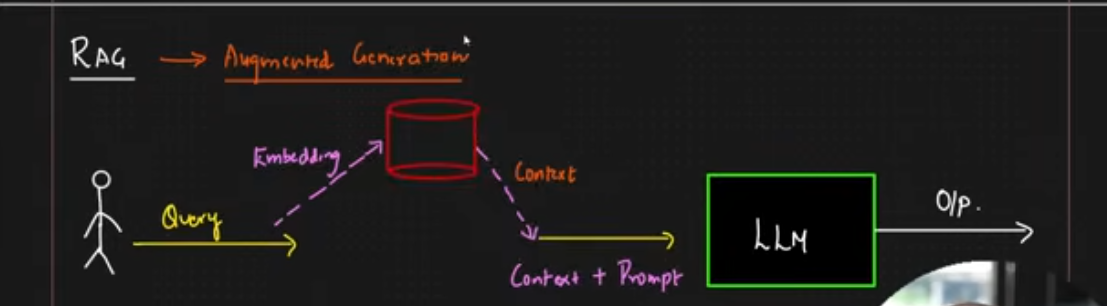

In [73]:
### Simple RAG pipeline with Groq LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

### Initialize the Groq LLM (set your GROQ_API_KEY in environment)
groq_api_key = os.getenv("GROQ_API_KEY")

llm=ChatGroq(groq_api_key=groq_api_key,model_name="gemma2-9b-it",temperature=0.1,max_tokens=1024)

## 2. Simple RAG function: retrieve context + generate response
def rag_simple(query,retriever,llm,top_k=3):
    ## retriever the context
    results=retriever.retrieve(query,top_k=top_k)
    context="\n\n".join([doc['content'] for doc in results]) if results else ""  # Combine retrieved documents into a single context string
    if not context:
        return "No relevant context found to answer the question."
    
    ## generate the answer using GROQ LLM
    prompt=f"""Use the following context to answer the question concisely.
Context:
{context}

Question: {query}

Answer:"""
    
    response = llm.invoke([prompt])
    return response.content

In [74]:
answer=rag_simple("What is attention mechanism?",rag_retriever,llm)
print(answer)

Retrieving documents for query: 'What is attention mechanism?'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 documents...


Batches: 100%|██████████| 1/1 [00:00<00:00, 53.12it/s]

Embeddings generated successfully.
Retrieved 0 documents (after filtering)
No relevant context found to answer the question.


## Enhanced RAG Pipeline Features

In [75]:
# --- Enhanced RAG Pipeline Features ---
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("Hard Negative Mining Technqiues", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'Hard Negative Mining Technqiues'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 documents...


Batches: 100%|██████████| 1/1 [00:00<00:00, 48.66it/s]

Embeddings generated successfully.
Retrieved 0 documents (after filtering)
Answer: No relevant context found.
Sources: []
Confidence: 0.0
Context Preview: 


In [77]:
# --- Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []  # Store query history

    def query(self, question: str, top_k: int = 5, min_score: float = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:
        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation
            prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt])
            answer = response.content

        # Add citations to answer
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is work?", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieving documents for query: 'what is work?'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 documents...


Batches: 100%|██████████| 1/1 [00:00<00:00, 37.03it/s]

Embeddings generated successfully.
Retrieved 0 documents (after filtering)


AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
# Fixed advanced RAG prompt handling to avoid formatting issues when context contains braces.

def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}

    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])

    prompt = f"""Use the following context to answer the question concisely.
Context:
{context}

Question: {query}

Answer:"""
    response = llm.invoke([prompt])

    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output


class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []

    def query(self, question: str, top_k: int = 5, min_score: float = 0.2, stream: bool = False, summarize: bool = False) -> dict:
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]

            prompt = f"""Use the following context to answer the question concisely.
Context:
{context}

Question: {question}

Answer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()

            response = self.llm.invoke([prompt])
            answer = response.content

        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }


# Run this cell after the earlier setup cells to override the old definitions.
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is attention is all you need", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

- 4-Building RAG With Typesense- Lightning Fast,Open Source Search video 4do.